In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
monthly_demand = pd.read_csv(
    "../data/processed/monthly_demand_features.csv"
)

print("Shape:", monthly_demand.shape)

monthly_demand.head()

Shape: (79424, 15)


,StockCode,MonthYear,Monthly_Quantity,Monthly_Revenue,Monthly_Transactions,Average_Monthly_Price,Lag_1,Lag_2,Lag_3,Rolling_3_Month,Rolling_6_Month,Lag_1_Price,Price_Change_Pct,Price_Ratio,Log_Price_Ratio
0,10002,2009-12,215.0,185.30,20.0,0.977500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10002,2010-01,291.0,248.97,17.0,0.945294,215.0,NaN,NaN,NaN,NaN,0.977500,-3.294719,0.967053,-0.033502
2,10002,2010-02,257.0,220.07,15.0,0.958000,291.0,215.0,NaN,NaN,NaN,0.945294,1.344119,1.013441,0.013352
3,10002,2010-03,641.0,493.09,17.0,0.911111,257.0,291.0,215.0,254.333333,NaN,0.958000,-4.894456,0.951055,-0.050183
4,10002,2010-04,1132.0,843.73,24.0,0.924167,641.0,257.0,291.0,396.333333,NaN,0.911111,1.432927,1.014329,0.014228


In [18]:
print("Rows:", monthly_demand.shape[0])
print("Columns:", monthly_demand.shape[1])
print("Unique products:", monthly_demand["StockCode"].nunique())
print("Date range:", monthly_demand["MonthYear"].min(), "to", monthly_demand["MonthYear"].max())

Rows: 79424
Columns: 15
Unique products: 4912
Date range: 2009-12 to 2011-12


In [19]:
monthly_demand["MonthYear"] = pd.PeriodIndex(
    monthly_demand["MonthYear"],
    freq="M"
)

print(monthly_demand["MonthYear"].dtype)

period[M]


In [20]:
monthly_demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79424 entries, 0 to 79423
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype    
---  ------                 --------------  -----    
 0   StockCode              79424 non-null  object   
 1   MonthYear              79424 non-null  period[M]
 2   Monthly_Quantity       79424 non-null  float64  
 3   Monthly_Revenue        79424 non-null  float64  
 4   Monthly_Transactions   79424 non-null  float64  
 5   Average_Monthly_Price  66981 non-null  float64  
 6   Lag_1                  74512 non-null  float64  
 7   Lag_2                  69859 non-null  float64  
 8   Lag_3                  65323 non-null  float64  
 9   Rolling_3_Month        65323 non-null  float64  
 10  Rolling_6_Month        52786 non-null  float64  
 11  Lag_1_Price            62069 non-null  float64  
 12  Price_Change_Pct       56353 non-null  float64  
 13  Price_Ratio            56353 non-null  float64  
 14  Log_Price_Ratio       

In [21]:
monthly_demand.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Quantity,79424.0,140.873061,565.972350,0.000000,2.000000,21.000000,110.000000,80995.000000
Monthly_Revenue,79424.0,247.684981,981.129751,0.000000,6.600000,43.900000,196.020000,168469.600000
Monthly_Transactions,79424.0,12.495707,20.950016,0.000000,1.000000,5.000000,15.000000,487.000000
Average_Monthly_Price,66981.0,4.049648,43.371012,0.001000,1.250000,2.437778,4.300000,11062.060000
Lag_1,74512.0,143.928669,494.158920,0.000000,2.000000,22.000000,115.000000,74215.000000
Lag_2,69859.0,141.065546,490.738061,0.000000,2.000000,21.000000,113.000000,74215.000000
Lag_3,65323.0,139.497405,487.535619,0.000000,2.000000,21.000000,111.000000,74215.000000
Rolling_3_Month,65323.0,139.670754,361.476318,0.000000,4.000000,27.333333,124.333333,24738.333333
Rolling_6_Month,52786.0,136.694212,326.767397,0.000000,5.333333,32.833333,126.625000,12568.833333
Lag_1_Price,62069.0,3.861046,7.402972,0.001000,1.250000,2.431304,4.274667,295.000000


In [22]:
missing_summary = (
    monthly_demand.isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing_summary)

Rolling_6_Month          26638
Log_Price_Ratio          23071
Price_Ratio              23071
Price_Change_Pct         23071
Lag_1_Price              17355
Lag_3                    14101
Rolling_3_Month          14101
Average_Monthly_Price    12443
Lag_2                     9565
Lag_1                     4912
Monthly_Revenue              0
StockCode                    0
Monthly_Transactions         0
MonthYear                    0
Monthly_Quantity             0
dtype: int64


In [23]:
print(
    monthly_demand["Monthly_Quantity"].describe()
)

count    79424.000000
mean       140.873061
std        565.972350
min          0.000000
25%          2.000000
50%         21.000000
75%        110.000000
max      80995.000000
Name: Monthly_Quantity, dtype: float64


In [24]:
zero_demand_count = (
    monthly_demand["Monthly_Quantity"] == 0
).sum()

total_rows = len(monthly_demand)

zero_demand_percentage = (
    zero_demand_count / total_rows
) * 100

print("Zero-demand product-months:", zero_demand_count)
print("Total product-months:", total_rows)
print("Zero-demand percentage:", zero_demand_percentage)

Zero-demand product-months: 12443
Total product-months: 79424
Zero-demand percentage: 15.666549153908138


In [25]:
top_quantity_products = (
    monthly_demand
    .groupby("StockCode")["Monthly_Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_quantity_products)

StockCode
84077     106139.0
85099B     96757.0
21212      94884.0
85123A     94203.0
22197      88499.0
23843      80995.0
84879      80082.0
23166      78033.0
17003      70369.0
21977      56061.0
Name: Monthly_Quantity, dtype: float64


In [26]:
top_revenue_products = (
    monthly_demand
    .groupby("StockCode")["Monthly_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_revenue_products)

StockCode
22423     330590.32
85123A    257724.71
85099B    180569.34
23843     168469.60
47566     148318.28
84879     129324.49
22086     117760.29
23166      81700.92
79321      80540.88
22197      79520.20
Name: Monthly_Revenue, dtype: float64


In [28]:
monthly_trend = (
    monthly_demand
    .groupby("MonthYear")
    .agg(
        Total_Quantity=("Monthly_Quantity", "sum"),
        Total_Revenue=("Monthly_Revenue", "sum"),
        Active_Products=("StockCode", "nunique")
    )
    .reset_index()
)

monthly_trend.head()

,MonthYear,Total_Quantity,Total_Revenue,Active_Products
0,2009-12,425263.0,798747.030,3054
1,2010-01,390440.0,612605.502,3157
2,2010-02,381634.0,538147.646,3196
3,2010-03,525054.0,762148.531,3356
4,2010-04,366090.0,647004.492,3286


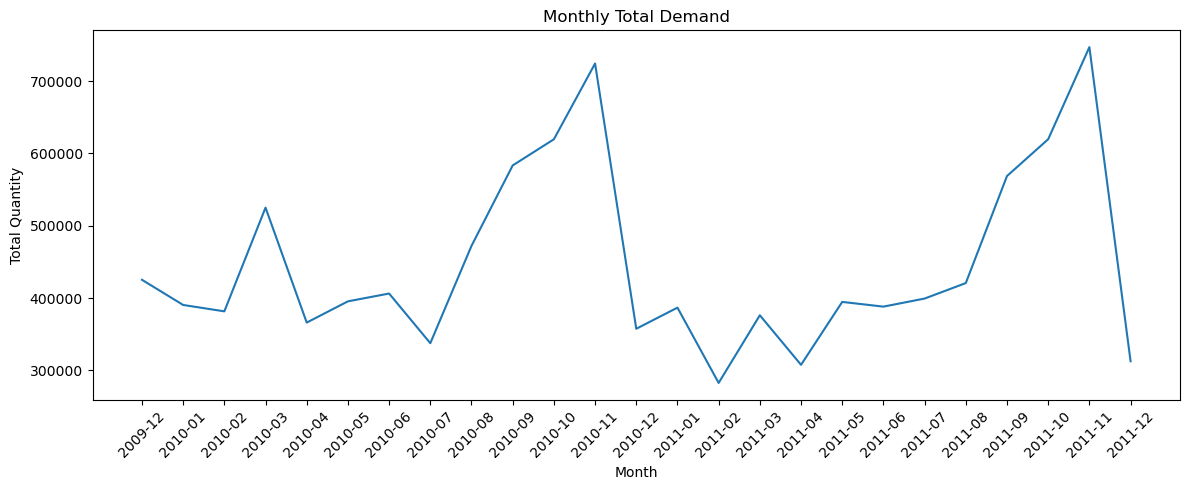

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_trend["MonthYear"].astype(str),
    monthly_trend["Total_Quantity"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.title("Monthly Total Demand")
plt.tight_layout()
plt.show()

In [30]:
monthly_demand["Average_Monthly_Price"].describe()

count    66981.000000
mean         4.049648
std         43.371012
min          0.001000
25%          1.250000
50%          2.437778
75%          4.300000
max      11062.060000
Name: Average_Monthly_Price, dtype: float64

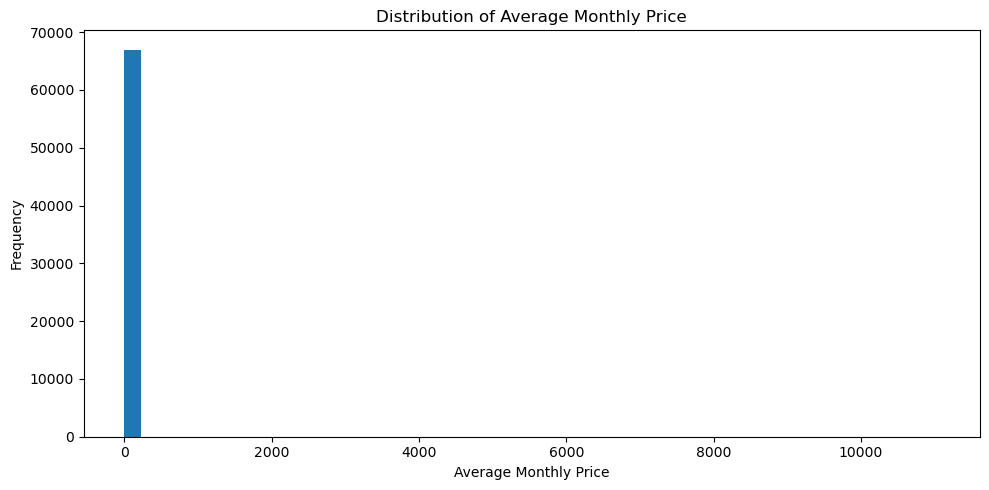

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(
    monthly_demand["Average_Monthly_Price"].dropna(),
    bins=50
)

plt.xlabel("Average Monthly Price")
plt.ylabel("Frequency")
plt.title("Distribution of Average Monthly Price")
plt.tight_layout()
plt.show()

In [32]:
price_demand = monthly_demand[
    [
        "Average_Monthly_Price",
        "Monthly_Quantity"
    ]
].dropna()

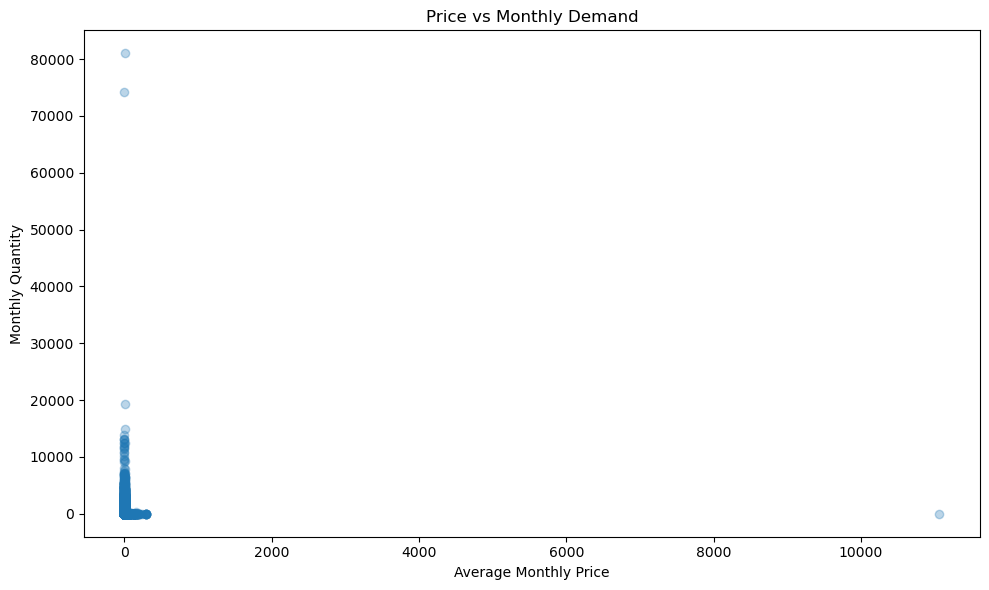

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(
    price_demand["Average_Monthly_Price"],
    price_demand["Monthly_Quantity"],
    alpha=0.3
)

plt.xlabel("Average Monthly Price")
plt.ylabel("Monthly Quantity")
plt.title("Price vs Monthly Demand")
plt.tight_layout()
plt.show()

In [34]:
correlation_columns = [
    "Monthly_Quantity",
    "Monthly_Revenue",
    "Monthly_Transactions",
    "Average_Monthly_Price",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_3_Month",
    "Rolling_6_Month",
    "Price_Change_Pct",
    "Price_Ratio",
    "Log_Price_Ratio"
]

correlation_matrix = (
    monthly_demand[correlation_columns]
    .corr()
)

correlation_matrix

,Monthly_Quantity,Monthly_Revenue,Monthly_Transactions,Average_Monthly_Price,Lag_1,Lag_2,Lag_3,Rolling_3_Month,Rolling_6_Month,Price_Change_Pct,Price_Ratio,Log_Price_Ratio
Monthly_Quantity,1.000000,0.767232,0.451970,-0.012112,0.507246,0.432814,0.415607,0.629685,0.684157,-0.030310,-0.030310,-0.029891
Monthly_Revenue,0.767232,1.000000,0.565953,0.046127,0.372195,0.321454,0.291042,0.449076,0.455121,-0.011137,-0.011137,0.010758
Monthly_Transactions,0.451970,0.565953,1.000000,-0.010421,0.450693,0.399762,0.364305,0.558170,0.574709,-0.026632,-0.026632,0.023739
Average_Monthly_Price,-0.012112,0.046127,-0.010421,1.000000,-0.085117,-0.084329,-0.085560,-0.099581,-0.110407,0.044011,0.044011,0.064101
Lag_1,0.507246,0.372195,0.450693,-0.085117,1.000000,0.517343,0.449446,0.824319,0.786921,0.039103,0.039103,0.064094
Lag_2,0.432814,0.321454,0.399762,-0.084329,0.517343,1.000000,0.514902,0.850601,0.828557,0.008777,0.008777,0.028832
Lag_3,0.415607,0.291042,0.364305,-0.085560,0.449446,0.514902,1.000000,0.814329,0.823697,-0.006668,-0.006668,0.019631
Rolling_3_Month,0.629685,0.449076,0.558170,-0.099581,0.824319,0.850601,0.814329,1.000000,0.917507,0.016647,0.016647,0.044463
Rolling_6_Month,0.684157,0.455121,0.574709,-0.110407,0.786921,0.828557,0.823697,0.917507,1.000000,0.003602,0.003602,0.035642
Price_Change_Pct,-0.030310,-0.011137,-0.026632,0.044011,0.039103,0.008777,-0.006668,0.016647,0.003602,1.000000,1.000000,0.771562


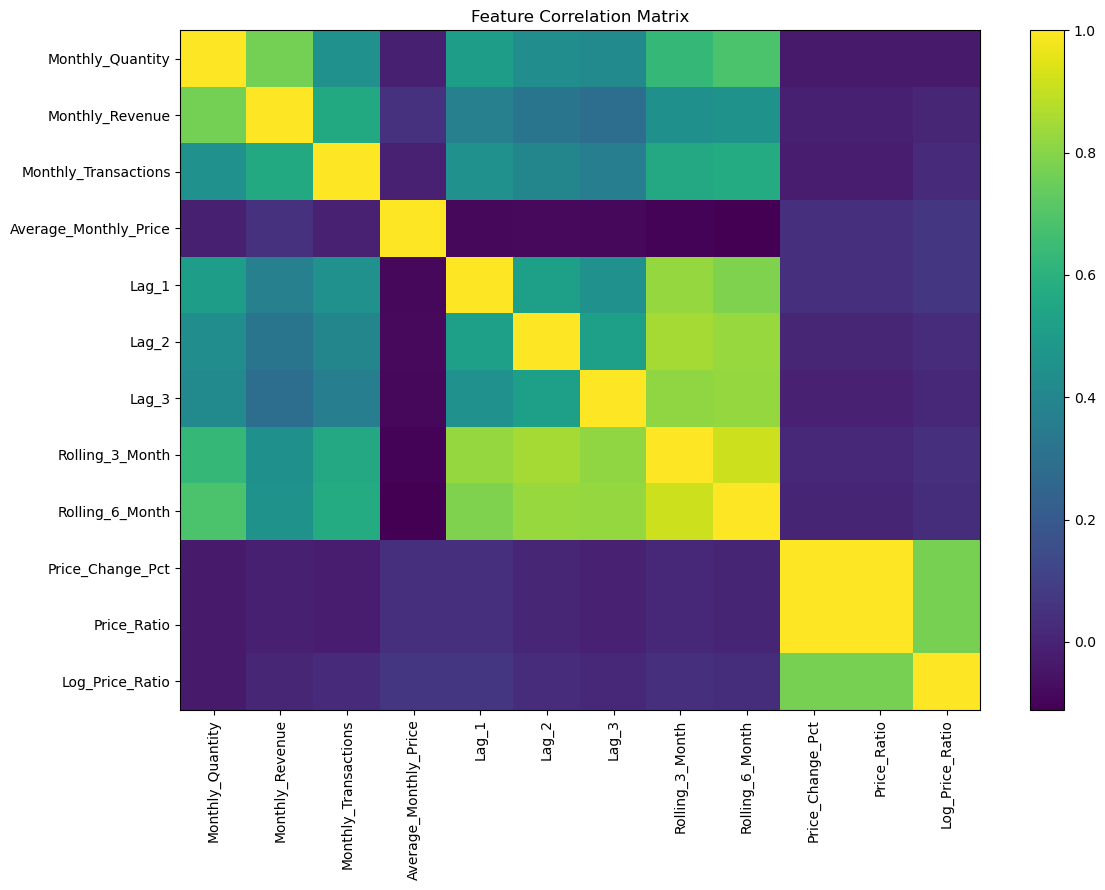

In [35]:
plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [36]:
monthly_demand["Month"] = monthly_demand["MonthYear"].dt.month

In [37]:
monthly_demand["Month_Name"] = monthly_demand["MonthYear"].dt.strftime("%b")

In [38]:
seasonality = (
    monthly_demand
    .groupby(["Month", "Month_Name"])["Monthly_Quantity"]
    .mean()
    .reset_index()
    .sort_values("Month")
)

seasonality

,Month,Month_Name,Monthly_Quantity
0,1,Jan,122.739419
1,2,Feb,104.609291
2,3,Mar,138.377399
3,4,Apr,104.766910
4,5,May,123.052328
5,6,Jun,122.857408
6,7,Jul,114.635968
7,8,Aug,139.968177
8,9,Sep,178.981513
9,10,Oct,190.257485


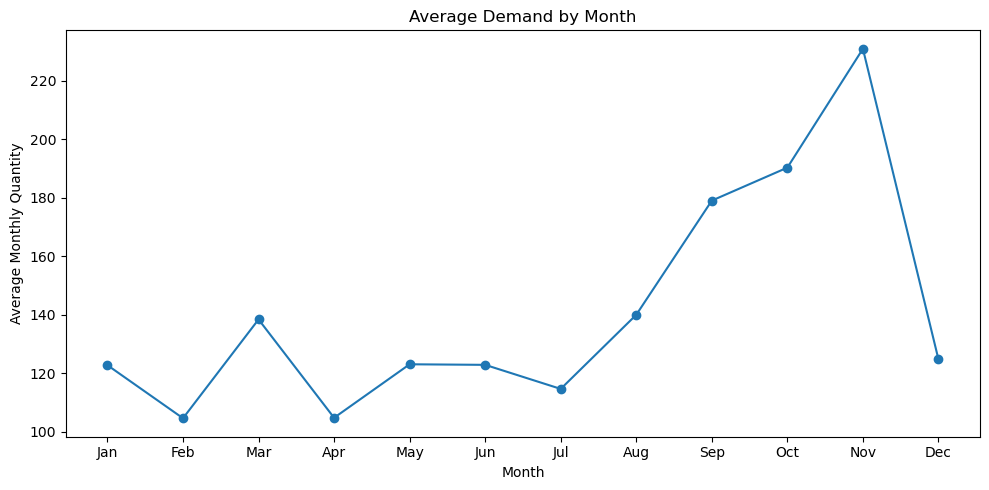

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    seasonality["Month_Name"],
    seasonality["Monthly_Quantity"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Monthly Quantity")
plt.title("Average Demand by Month")
plt.tight_layout()
plt.show()

In [40]:
monthly_seasonality = (
    monthly_demand
    .groupby(["Month", "Month_Name"])["Monthly_Quantity"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

monthly_seasonality

,Month,Month_Name,Monthly_Quantity
0,1,Jan,777186.0
1,2,Feb,664269.0
2,3,Mar,901252.0
3,4,Apr,673756.0
4,5,May,790119.0
5,6,Jun,794396.0
6,7,Jul,736880.0
7,8,Aug,892857.0
8,9,Sep,1152104.0
9,10,Oct,1239147.0


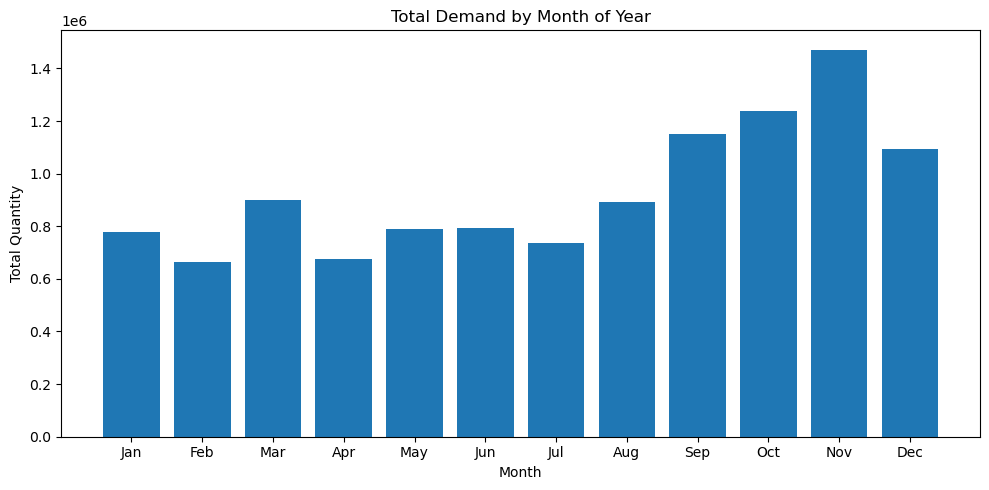

In [41]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_seasonality["Month_Name"],
    monthly_seasonality["Monthly_Quantity"]
)

plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.title("Total Demand by Month of Year")
plt.tight_layout()
plt.show()

In [42]:
monthly_trend

,MonthYear,Total_Quantity,Total_Revenue,Active_Products
0,2009-12,425263.0,798747.030,3054
1,2010-01,390440.0,612605.502,3157
2,2010-02,381634.0,538147.646,3196
3,2010-03,525054.0,762148.531,3356
4,2010-04,366090.0,647004.492,3286
5,2010-05,395451.0,644006.870,3302
6,2010-06,406255.0,697864.870,3321
7,2010-07,337577.0,633899.420,3325
8,2010-08,472147.0,675079.890,3320
9,2010-09,583381.0,869772.161,3340


In [43]:
monthly_trend.tail(15)

,MonthYear,Total_Quantity,Total_Revenue,Active_Products
10,2010-10,619532.0,1095413.630,3383
11,2010-11,724300.0,1431193.112,3364
12,2010-12,357543.0,776332.500,3260
13,2011-01,386746.0,670654.460,3175
14,2011-02,282635.0,508081.540,3154
15,2011-03,376198.0,690591.840,3157
16,2011-04,307666.0,515914.661,3145
17,2011-05,394668.0,740487.330,3119
18,2011-06,388141.0,738233.990,3145
19,2011-07,399303.0,688802.671,3103


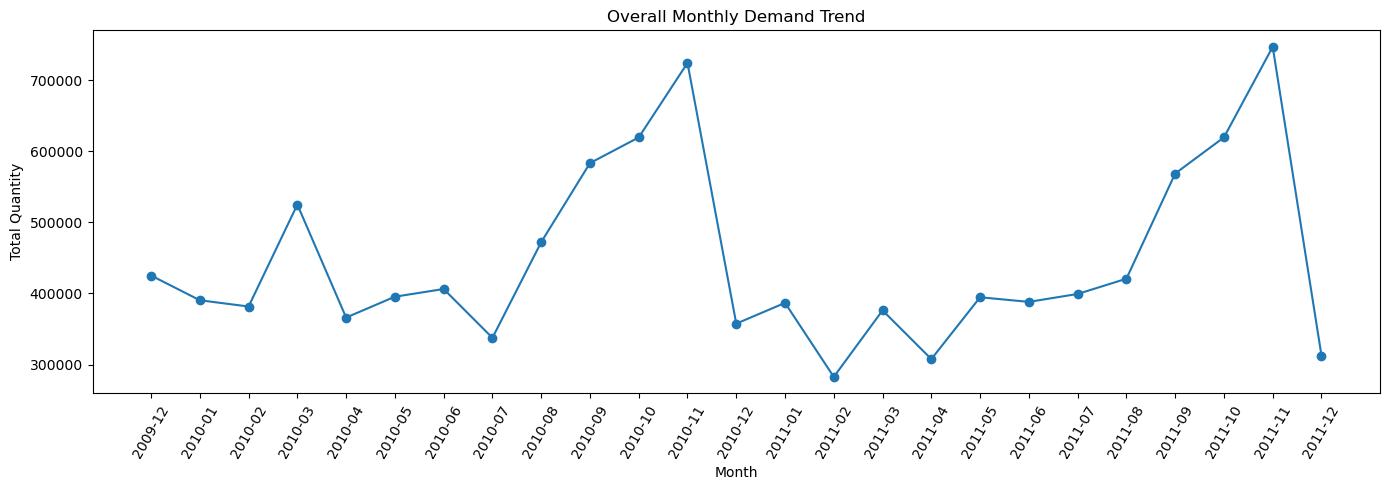

In [44]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_trend["MonthYear"].astype(str),
    monthly_trend["Total_Quantity"],
    marker="o"
)

plt.xticks(rotation=60)
plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.title("Overall Monthly Demand Trend")
plt.tight_layout()
plt.show()

In [45]:
product_month_counts = (
    monthly_demand
    .groupby("StockCode")["MonthYear"]
    .nunique()
)

print(product_month_counts.describe())

count    4912.000000
mean       16.169381
std         8.517342
min         1.000000
25%         8.000000
50%        18.000000
75%        25.000000
max        25.000000
Name: MonthYear, dtype: float64


In [46]:
print(
    "Products with only 1 month:",
    (product_month_counts == 1).sum()
)

print(
    "Products with 6 or fewer months:",
    (product_month_counts <= 6).sum()
)

print(
    "Products with more than 12 months:",
    (product_month_counts > 12).sum()
)

Products with only 1 month: 259
Products with 6 or fewer months: 967
Products with more than 12 months: 3186


In [47]:
product_demand = (
    monthly_demand
    .groupby("StockCode")["Monthly_Quantity"]
    .sum()
    .sort_values(ascending=False)
)

total_demand = product_demand.sum()

top_10_demand = product_demand.head(10).sum()

print("Total demand:", total_demand)
print("Top 10 products demand:", top_10_demand)
print(
    "Top 10 contribution:",
    (top_10_demand / total_demand) * 100,
    "%"
)

Total demand: 11188702.0
Top 10 products demand: 846022.0
Top 10 contribution: 7.561395414767504 %
